In [1]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
import matplotlib.pyplot as plt

np.random.seed(2026)


In [2]:
catalog = pd.DataFrame([
    ("Paperbacks from Hell: Horror Classics", "1970s-1980s", "classic_horror", 3.50, 12.99),
    ("Night Visions: British Gothic", "1980s-1990s", "gothic_horror", 4.00, 13.49),
    ("Creeping Shadows", "1990s", "psychological_horror", 3.80, 11.99),
    ("Tales from Fog and Mire", "1970s", "folk_horror", 3.60, 12.49),
    ("Ghosts of the Moors", "1970s", "haunting", 3.30, 10.99),
    ("The Last Devil in Devon", "1980s", "occult_horror", 4.20, 14.50),
    ("Terror on the Tyne", "1990s", "urban_horror", 3.70, 12.99),
    ("Midnight Harvest", "1960s", "cult_horror", 3.10, 10.49),
], columns=["title","era","subgenre","wholesale_cost","retail_price"])


In [4]:
@dataclass
class BookBusiness:
    name: str
    channel: str
    weekly_fixed_cost: float
    markup: float
    online_share: float
    used_share: float
    member_discount: float
    cafe_exists: bool
    cafe_attach_rate: float
    cafe_avg_spend: float
    footfall_mean: float
    footfall_sd: float

# 3 UK businesses
biz1 = BookBusiness(
    name="High Street Bookshop Co.",
    channel="physical",
    weekly_fixed_cost=4200,
    markup=1.10,
    online_share=0.05,
    used_share=0.25,
    member_discount=0.10,
    cafe_exists=True,
    cafe_attach_rate=0.12,
    cafe_avg_spend=4.50,
    footfall_mean=320,
    footfall_sd=60
)

biz2 = BookBusiness(
    name="OnlineBooks UK",
    channel="online",
    weekly_fixed_cost=3100,
    markup=1.05,
    online_share=0.85,
    used_share=0.15,
    member_discount=0.05,
    cafe_exists=False,
    cafe_attach_rate=0.00,
    cafe_avg_spend=0.0,
    footfall_mean=950,
    footfall_sd=125
)

biz3 = BookBusiness(
    name="Charity & Rare Books Ltd.",
    channel="hybrid",
    weekly_fixed_cost=2100,
    markup=1.08,
    online_share=0.25,
    used_share=0.65,
    member_discount=0.0,
    cafe_exists=False,
    cafe_attach_rate=0.00,
    cafe_avg_spend=0.0,
    footfall_mean=480,
    footfall_sd=95
)

businesses = [biz1, biz2, biz3]



In [5]:
segments = pd.DataFrame([
    # segment, population share, buy_prob, avg_books_per_tx
    ("Gen_Z_Readers",      0.27, 0.16, 1.4),
    ("Young_Adults",       0.32, 0.19, 1.6),
    ("Mid_Age_Fictioneers",0.24, 0.21, 1.7),
    ("Older_Loyal_Readers",0.17, 0.25, 1.9),
], columns=["segment","share","buy_prob","avg_books"])


In [6]:
def simulate_uk_sales(start="2025-01-01", end="2025-12-31"):
    weeks = pd.date_range(start, end, freq="W")
    rows = []

    for biz in businesses:
        for w in weeks:
            # footfall or traffic
            base_traffic = max(1, np.random.normal(biz.footfall_mean, biz.footfall_sd))
            # allocate segments
            seg_counts = np.random.multinomial(int(base_traffic), segments["share"])

            for (seg_name, seg_n) in zip(segments["segment"], seg_counts):
                for _ in range(seg_n):
                    # purchase decision
                    buy = np.random.rand() < segments.loc[segments.segment==seg_name, "buy_prob"].values[0]
                    if buy:
                        num_books = int(max(1, np.random.poisson(segments.loc[segments.segment==seg_name,"avg_books"].values[0])))
                        # pick books
                        titles = catalog.sample(n=num_books, replace=True)

                        for __ in range(num_books):
                            is_used = np.random.rand() < biz.used_share
                            retail = titles.iloc[__]["retail_price"] * biz.markup
                            cost   = titles.iloc[__]["wholesale_cost"]
                            if is_used:
                                retail *= 0.75
                                cost   *= 0.60

                            # apply online vs offline logic
                            if biz.channel=="online":
                                retail *= 0.95  # small online price cut

                            rows.append({
                                "week": str(w.isocalendar().week),
                                "business": biz.name,
                                "segment": seg_name,
                                "is_used": is_used,
                                "book_revenue": retail,
                                "book_cogs": cost
                            })
                    # cafe
                    if biz.cafe_exists and np.random.rand() < biz.cafe_attach_rate:
                        rows.append({
                            "week": str(w.isocalendar().week),
                            "business": biz.name,
                            "segment": seg_name,
                            "is_used": None,
                            "book_revenue": 0,
                            "book_cogs": 0,
                            "cafe_revenue": biz.cafe_avg_spend,
                            "cafe_cogs": biz.cafe_avg_spend*0.40
                        })
    df = pd.DataFrame(rows).fillna(0)
    df["total_revenue"] = df["book_revenue"] + df.get("cafe_revenue", 0)
    df["total_cogs"] = df["book_cogs"] + df.get("cafe_cogs", 0)
    df["gross_profit"] = df["total_revenue"] - df["total_cogs"]
    return df

df_uk = simulate_uk_sales()


In [7]:
weekly = df_uk.groupby(["business","week"], as_index=False).agg(
    revenue=("total_revenue","sum"),
    cogs=("total_cogs","sum"),
    gross_profit=("gross_profit","sum")
)

# Add fixed costs
fixed_costs = {biz.name: biz.weekly_fixed_cost for biz in businesses}
weekly["fixed_cost"] = weekly["business"].map(fixed_costs)
weekly["net_profit"] = weekly["gross_profit"] - weekly["fixed_cost"]

yearly = weekly.groupby("business", as_index=False).agg(
    weeks=("week","nunique"),
    avg_weekly_net=("net_profit","mean"),
    yearly_net_profit=("net_profit","sum")
)

weekly.head(), yearly


(                    business week    revenue    cogs  gross_profit  \
 0  Charity & Rare Books Ltd.    1  2130.0435  510.50     1619.5435   
 1  Charity & Rare Books Ltd.   10  2500.8777  597.52     1903.3577   
 2  Charity & Rare Books Ltd.   11  2703.3696  648.52     2054.8496   
 3  Charity & Rare Books Ltd.   12  2666.9628  635.56     2031.4028   
 4  Charity & Rare Books Ltd.   13  1249.4493  290.42      959.0293   
 
    fixed_cost  net_profit  
 0        2100   -480.4565  
 1        2100   -196.6423  
 2        2100    -45.1504  
 3        2100    -68.5972  
 4        2100  -1140.9707  ,
                     business  weeks  avg_weekly_net  yearly_net_profit
 0  Charity & Rare Books Ltd.     52     -556.946050      -28961.194600
 1   High Street Bookshop Co.     52    -2973.518437     -154622.958750
 2             OnlineBooks UK     52     -200.423831      -10422.039238)

In [8]:
seg_distribution = df_uk.groupby(["business","segment"]).size().reset_index(name="count")
genre_summary = df_uk[df_uk["book_revenue"]>0].groupby(["business"]).agg(
    total_books_sold=("book_revenue","count")
)

seg_distribution, genre_summary


(                     business              segment  count
 0   Charity & Rare Books Ltd.        Gen_Z_Readers   1836
 1   Charity & Rare Books Ltd.  Mid_Age_Fictioneers   2456
 2   Charity & Rare Books Ltd.  Older_Loyal_Readers   2350
 3   Charity & Rare Books Ltd.         Young_Adults   2688
 4    High Street Bookshop Co.        Gen_Z_Readers   1690
 5    High Street Bookshop Co.  Mid_Age_Fictioneers   2085
 6    High Street Bookshop Co.  Older_Loyal_Readers   1811
 7    High Street Bookshop Co.         Young_Adults   2509
 8              OnlineBooks UK        Gen_Z_Readers   3492
 9              OnlineBooks UK  Mid_Age_Fictioneers   4561
 10             OnlineBooks UK  Older_Loyal_Readers   4122
 11             OnlineBooks UK         Young_Adults   5426,
                            total_books_sold
 business                                   
 Charity & Rare Books Ltd.              9330
 High Street Bookshop Co.               6079
 OnlineBooks UK                        17601)

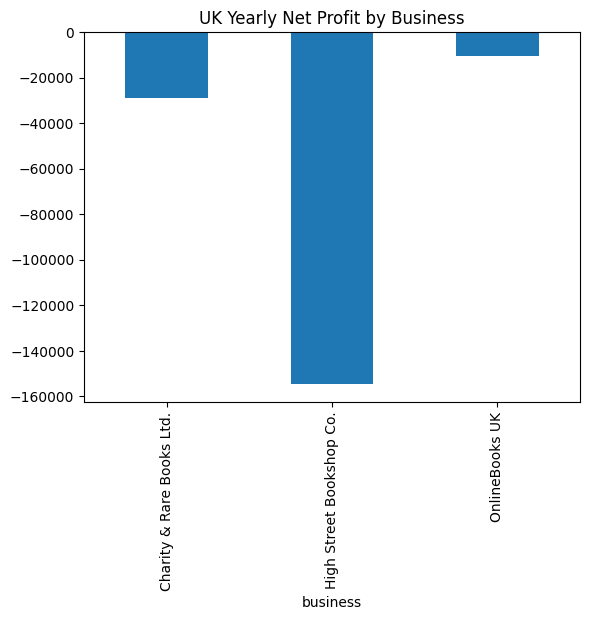

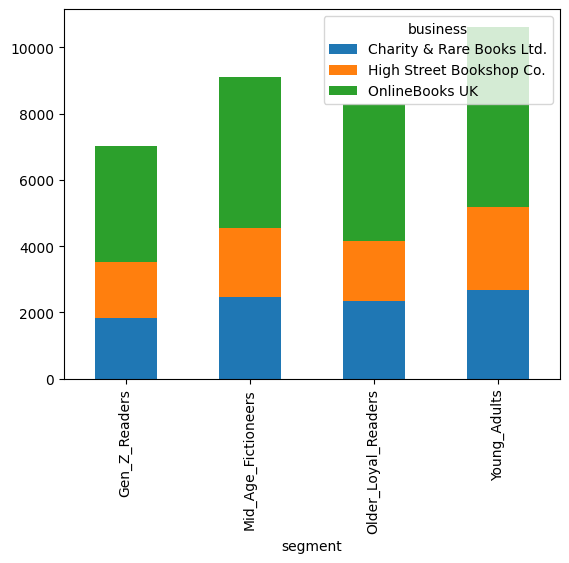

In [9]:
# Yearly net profit comparison
yearly.set_index("business")["yearly_net_profit"].plot(kind="bar", title="UK Yearly Net Profit by Business")
plt.show()

# Segment distribution
seg_distribution.pivot(index="segment",columns="business",values="count").plot(kind="bar", stacked=True)
plt.show()
